# Intro
Purpose:

    Make some plots of the PACE-PAX aerosol and cloud from the Twin Otter (TO)

Input:

    None

Output:

    Figure and save files

Keywords:

    none

Dependencies:
  - load_utils.py
  - matplotlib
  - numpy
  - write_utils
  - path_utils

Needed Files:
  - NA
  - ...

Modification History:

    Written: Samuel LeBlanc, Santa Cruz, CA, 2025-07-29
    Modified:

# Prepare python environment

In [78]:
import numpy as np
#import Sp_parameters as Sp
import load_utils as lu
import write_utils as wu
from path_utils import getpath
import matplotlib.pyplot as plt
%matplotlib inline
import os
import pandas as pd
from datetime import datetime

In [79]:
name = 'PACEPAX_TO'
vv = 'v0'
fp = getpath(name)

Return path named:  PACEPAX_TO /data2/PACEPAX/data/TO/


# Load files

In [81]:
f = os.listdir(fp)
f.sort()
f

['PACE-PAX_TO_LWC_aerosolnum_20240829.png',
 'PACE-PAX_TO_LWC_aerosolnum_20240904.png',
 'PACE-PAX_TO_LWC_aerosolnum_20240906_L1.png',
 'PACE-PAX_TO_LWC_aerosolnum_20240906_L2.png',
 'PACE-PAX_TO_LWC_aerosolnum_20240907.png',
 'PACE-PAX_TO_LWC_aerosolnum_20240908.png',
 'PACE-PAX_TO_LWC_aerosolnum_20240912.png',
 'PACE-PAX_TO_LWC_aerosolnum_20240913_L1.png',
 'PACE-PAX_TO_LWC_aerosolnum_20240913_L2.png',
 'PACE-PAX_TO_LWC_aerosolnum_20240919_L1.png',
 'PACE-PAX_TO_LWC_aerosolnum_20240919_L2.png',
 'PACE-PAX_TO_LWC_aerosolnum_20240920.png',
 'PACE-PAX_TO_LWC_aerosolnum_20240922.png',
 'PACE-PAX_TO_LWC_aerosolnum_20240923.png',
 'PACE-PAX_TO_LWC_aerosolnum_20240924.png',
 'PACE-PAX_TO_LWC_aerosolnum_20240926.png',
 'PACE-PAX_TO_LWC_aerosolnum_20240927.png',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240903_R0.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240904_R0.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240906_R0_L1.ict',
 'PACEPAX-LARGE-MICROPHYSICAL_CIRPAS-TO_20240906_R0_L2.ic

In [82]:
metnav = {}
for fn in f:
    if (fn.endswith('.ict') & ('MetNav' in fn)): 
        daystr = fn.split('_')[2] 
        if len(fn.split('_'))>4: daystr = daystr +'_'+ fn.split('_')[4].split('.')[0]
        print('doing : '+daystr)

        metnav[daystr] = lu.load_ict(os.path.join(fp,fn))

doing : 20240829
('Time_Start', 'Latitude', 'Longitude', 'GPS_Altitude', 'Pressure_Altitude', 'Radar_Altitude', 'Pitch_Angle', 'Roll_Angle', 'True_Heading', 'True_Air_Speed', 'East_Vel_Aircraft', 'North_Vel_Aircraft', 'Up_Vel_Aircraft', 'Press_Ambient', 'Temp_Ambient', 'Temp_DewPoint', 'Relative_Humidity_Ambient', 'Potential_Temp', 'Equivalent_Potential_Temp', 'Virtual_Potential_Temp', 'Virtual_Temp', 'Wind_Speed', 'Wind_Direction', 'Vert_WindSpeed', 'H2OMR', 'SPHum', 'PSA_PVM', 'LWC_PVM', 'Re_PVM', 'IRT_Nad', 'SPNT', 'SPND', 'UF_CPC_3025', 'PCASP', 'CASF_DNCN', 'CASF_Vol', 'CIP_DNCN', 'CIP_Vol', 'LWC_Wire')
doing : 20240903
('Time_Start', 'Latitude', 'Longitude', 'GPS_Altitude', 'Pressure_Altitude', 'Radar_Altitude', 'Pitch_Angle', 'Roll_Angle', 'True_Heading', 'True_Air_Speed', 'East_Vel_Aircraft', 'North_Vel_Aircraft', 'Up_Vel_Aircraft', 'Press_Ambient', 'Temp_Ambient', 'Temp_DewPoint', 'Relative_Humidity_Ambient', 'Potential_Temp', 'Equivalent_Potential_Temp', 'Virtual_Potential_Te

In [83]:
aer = {}
for fn in f:
    if (fn.endswith('.ict') & ('MICROPHYSICAL' in fn)): 
        daystr = fn.split('_')[2] 
        if len(fn.split('_'))>4: daystr = daystr +'_'+ fn.split('_')[4].split('.')[0]
        print('doing : '+daystr)

        aer[daystr] = lu.load_ict(os.path.join(fp,fn))

doing : 20240903
('Time_Mid', 'IntegN_100to1000nm_UHSAS', 'IntegS_100to1000nm_UHSAS', 'IntegV_100to1000nm_UHSAS', 'IntegN_gt1000nm_APS', 'IntegS_gt1000nm_APS', 'IntegV_gt1000nm_APS', 'stdPT')
doing : 20240904
('Time_Mid', 'IntegN_100to1000nm_UHSAS', 'IntegS_100to1000nm_UHSAS', 'IntegV_100to1000nm_UHSAS', 'IntegN_gt1000nm_APS', 'IntegS_gt1000nm_APS', 'IntegV_gt1000nm_APS', 'stdPT')
doing : 20240906_L1
('Time_Mid', 'IntegN_100to1000nm_UHSAS', 'IntegS_100to1000nm_UHSAS', 'IntegV_100to1000nm_UHSAS', 'IntegN_gt1000nm_APS', 'IntegS_gt1000nm_APS', 'IntegV_gt1000nm_APS', 'stdPT')
doing : 20240906_L2
('Time_Mid', 'IntegN_100to1000nm_UHSAS', 'IntegS_100to1000nm_UHSAS', 'IntegV_100to1000nm_UHSAS', 'IntegN_gt1000nm_APS', 'IntegS_gt1000nm_APS', 'IntegV_gt1000nm_APS', 'stdPT')
doing : 20240907
('Time_Mid', 'IntegN_100to1000nm_UHSAS', 'IntegS_100to1000nm_UHSAS', 'IntegV_100to1000nm_UHSAS', 'IntegN_gt1000nm_APS', 'IntegS_gt1000nm_APS', 'IntegV_gt1000nm_APS', 'stdPT')
doing : 20240908
('Time_Mid', 'Int

# Plot out the different values

## Interpolate the alt, lat, lon to the aerosol values

In [84]:
from scipy.interpolate import interp1d
def inter(xold,yold,xnew):
    igood = np.isfinite(xold) & np.isfinite(yold)
    fx = interp1d(xold[igood],yold[igood],fill_value="extrapolate")
    return fx(xnew)

In [85]:
import numpy.lib.recfunctions as rfn

In [86]:
aern = {}
for k in list(aer.keys()):
    if not k in metnav: continue
    print(k)
    aern[k] = {}
    for ko in ['Latitude', 'Longitude', 'GPS_Altitude']:
        aern[k][ko] = inter(metnav[k]['Time_Start'],metnav[k][ko],aer[k]['Time_Mid'].data)
        #aer[k] = rfn.append_fields(aer[k],ko,inter(metnav[k]['Time_Start'],metnav[k][ko],aer[k]['Time_Mid'].data),dtypes='<f8')

20240903
20240904
20240906_L1
20240906_L2
20240907
20240908
20240912
20240913_L1
20240913_L2
20240919_L1
20240919_L2
20240920
20240922
20240923
20240924
20240926
20240927


## plot the aerosol number per alt

In [87]:
aer[k]

array([(73627., 800.24, 73.52, 2.78, 3.33, 53.91, 37.5 , 1.093),
       (73628., 787.34, 72.47, 2.86, 4.  , 86.9 , 63.57, 1.092),
       (73629., 758.66, 75.15, 3.18, 2.61, 39.98, 23.36, 1.092), ...,
       (84682., 401.4 , 45.42, 2.15, 3.43, 29.88, 11.85, 1.088),
       (84683., 384.72, 48.21, 2.41, 4.31, 30.49, 10.16, 1.087),
       (84684., 358.08, 40.27, 1.76, 3.92, 30.36, 10.09,   nan)],
      dtype=[('Time_Mid', '<f8'), ('IntegN_100to1000nm_UHSAS', '<f8'), ('IntegS_100to1000nm_UHSAS', '<f8'), ('IntegV_100to1000nm_UHSAS', '<f8'), ('IntegN_gt1000nm_APS', '<f8'), ('IntegS_gt1000nm_APS', '<f8'), ('IntegV_gt1000nm_APS', '<f8'), ('stdPT', '<f8')])

ValueError: array([66790., 66791., 66792., ..., 79304., 79305., 79306.]) is not a valid value for color

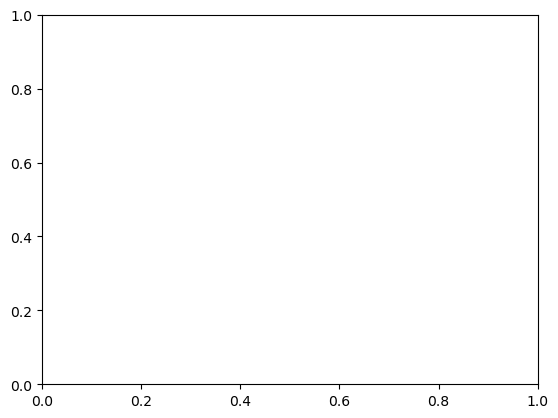

In [88]:
for k in list(aern.keys()):
    plt.figure()
    plt.plot(aer[k]['IntegN_100to1000nm_UHSAS'],aern[k]['GPS_Altitude'],'.',color=aer[k]['Time_Mid'])
    plt.xlabel('UHSAS aerosol #')
    plt.ylabel('GPS Altitude [m]')
    plt.title('TO Aerosol for:'+k)

## plot the Cloud LWC per alt against time

In [89]:
%matplotlib inline

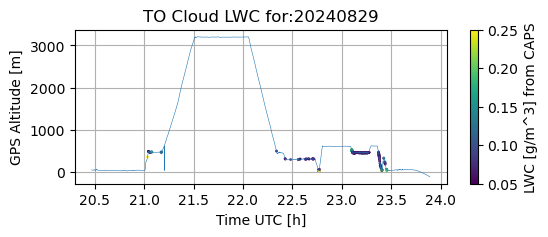

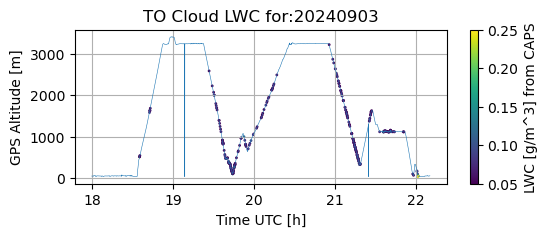

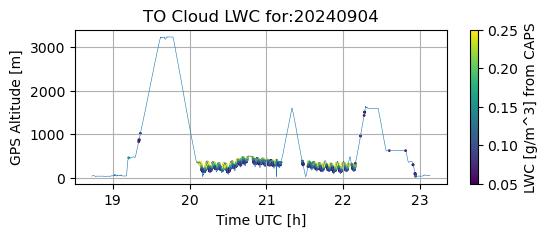

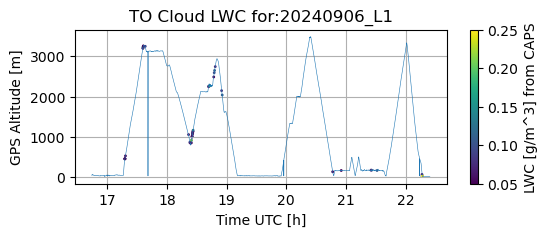

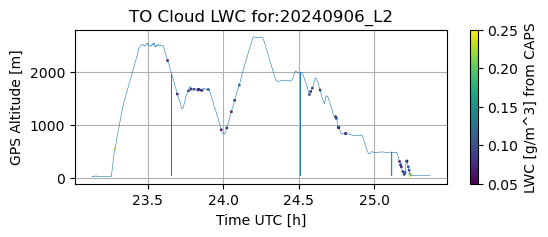

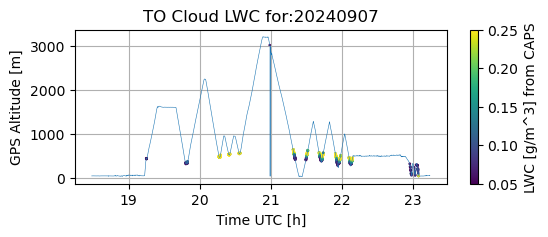

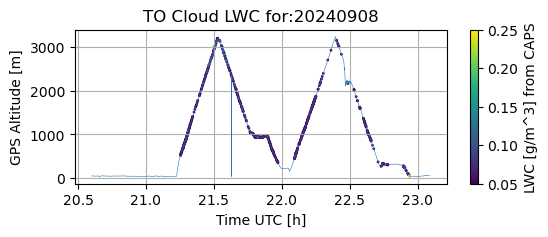

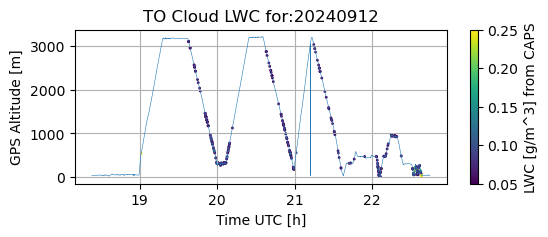

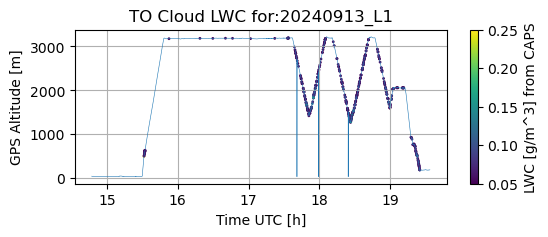

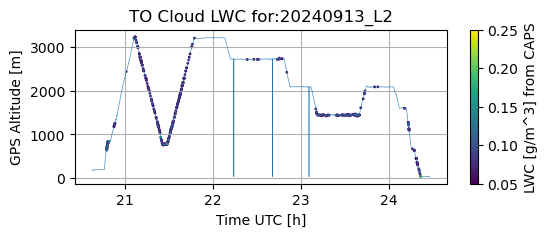

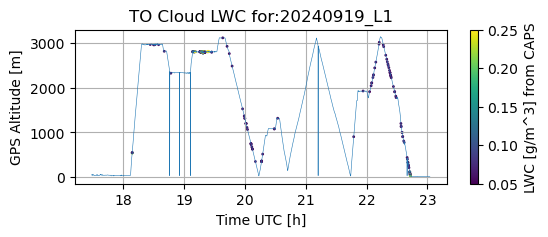

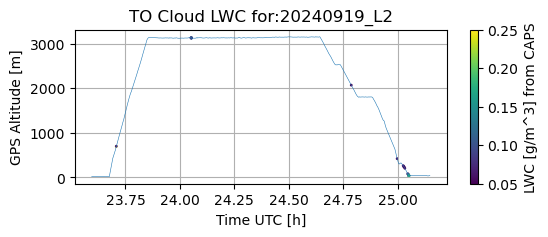

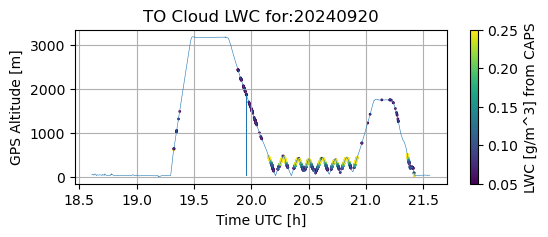

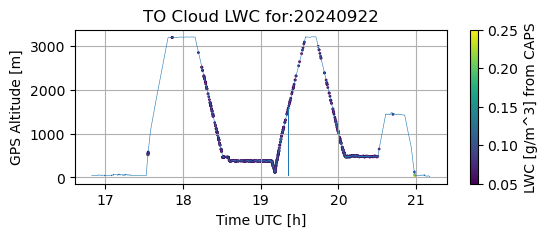

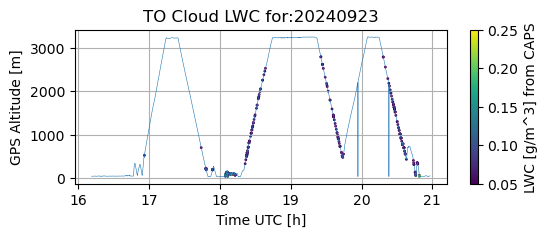

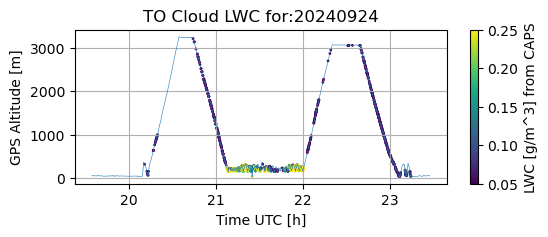

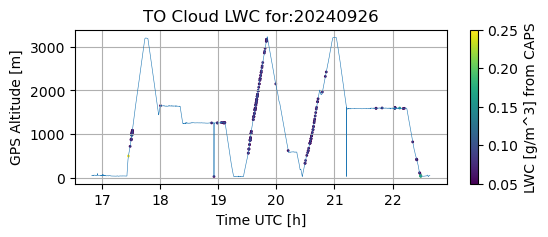

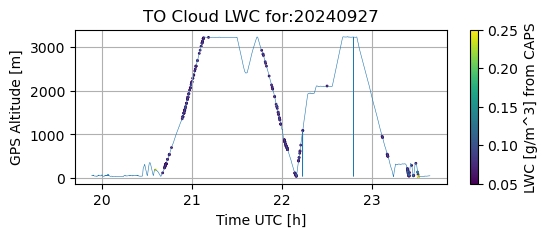

In [90]:
for k in list(metnav.keys()):
    plt.figure(figsize=(6,2))
    plt.plot(metnav[k]['Time_Start']/3600.0,metnav[k]['GPS_Altitude'],lw=0.4)#'.',color='gray')
    mask = metnav[k]['LWC_Wire'] > 0.05
    p = plt.scatter(metnav[k]['Time_Start'][mask]/3600.0,metnav[k]['GPS_Altitude'][mask],1,marker='o',c=metnav[k]['LWC_Wire'][mask], vmin=0.05, vmax=0.25)
    plt.xlabel('Time UTC [h]')
    plt.ylabel('GPS Altitude [m]')
    plt.title('TO Cloud LWC for:'+k)
    plt.colorbar(label='LWC [g/m^3] from CAPS')
    plt.grid()
    

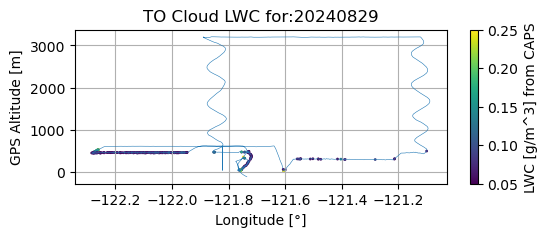

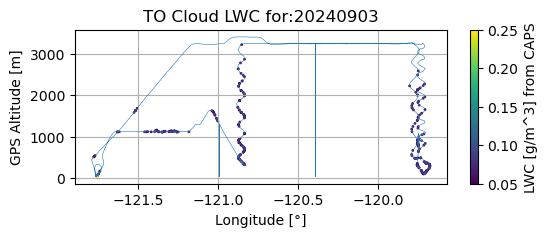

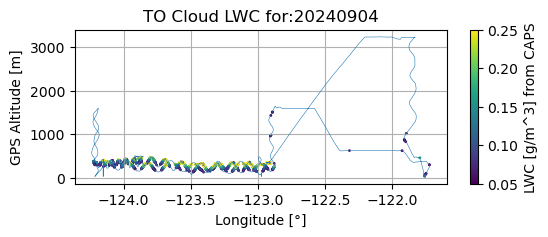

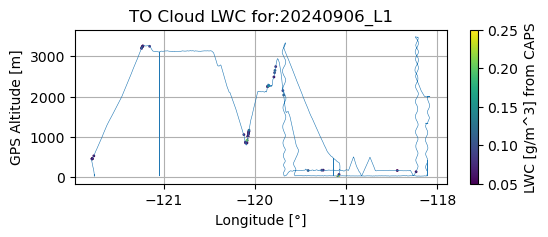

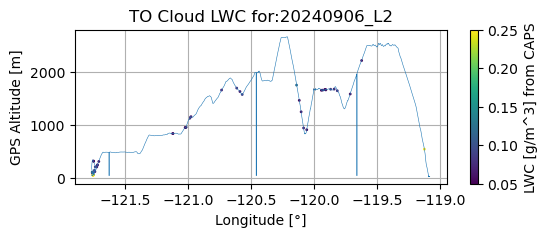

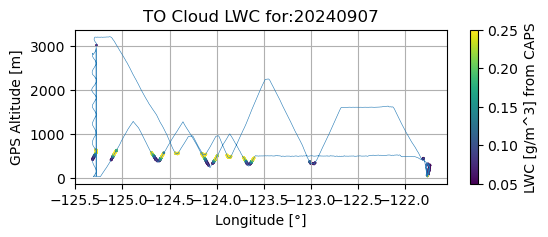

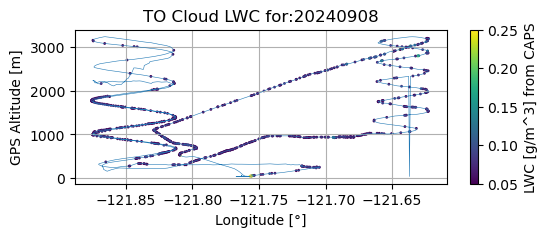

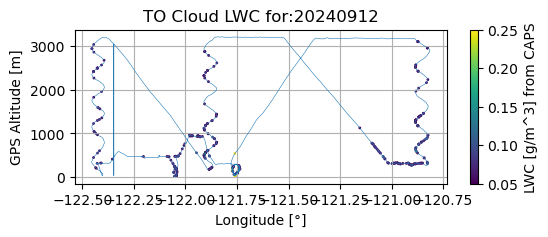

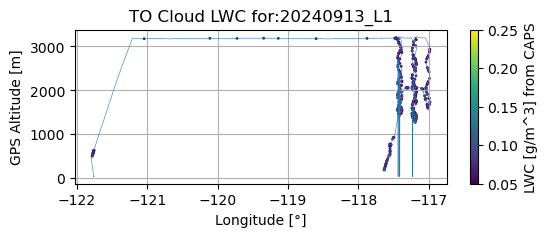

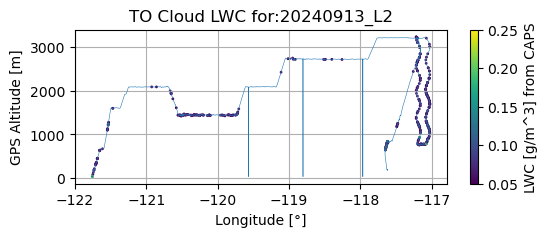

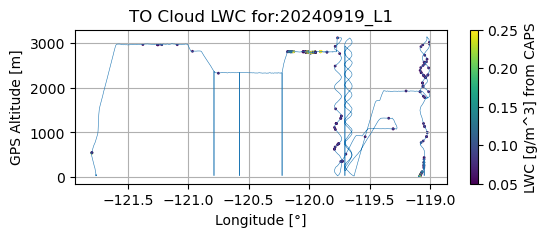

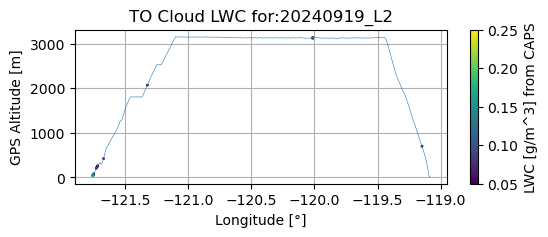

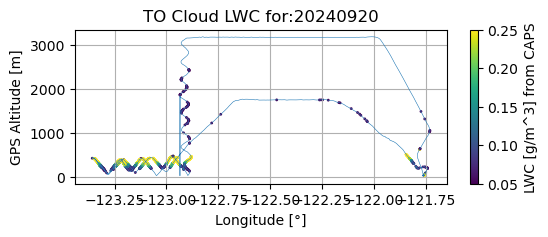

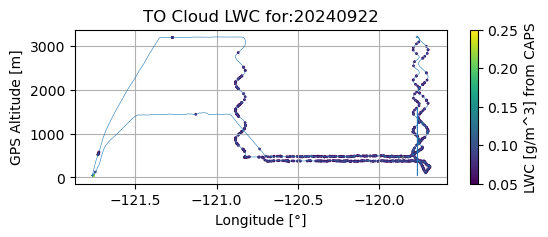

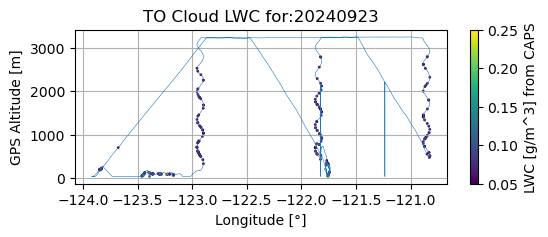

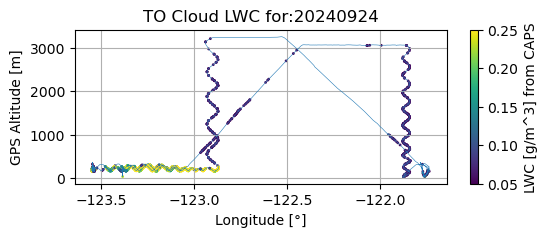

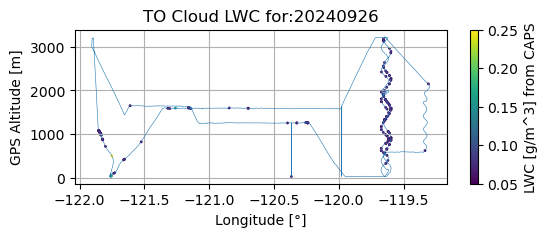

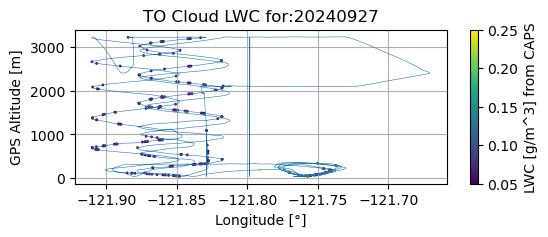

In [91]:
for k in list(metnav.keys()):
    plt.figure(figsize=(6,2))
    plt.plot(metnav[k]['Longitude'],metnav[k]['GPS_Altitude'],lw=0.4)#'.',color='gray')
    mask = metnav[k]['LWC_Wire'] > 0.05
    p = plt.scatter(metnav[k]['Longitude'][mask],metnav[k]['GPS_Altitude'][mask],1,marker='o',c=metnav[k]['LWC_Wire'][mask], vmin=0.05, vmax=0.25)
    plt.xlabel('Longitude [°]')
    plt.ylabel('GPS Altitude [m]')
    plt.title('TO Cloud LWC for:'+k)
    plt.colorbar(label='LWC [g/m^3] from CAPS')
    plt.grid()
    

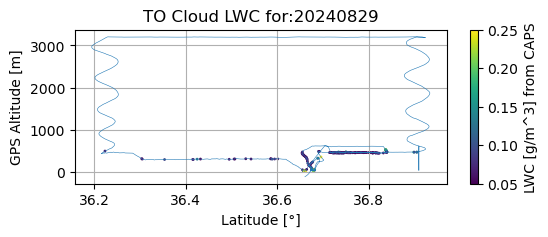

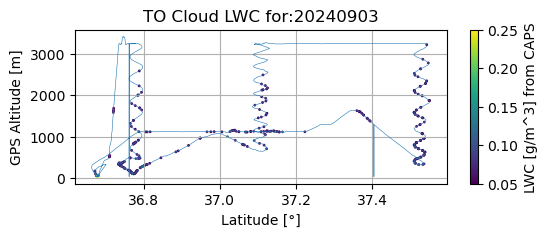

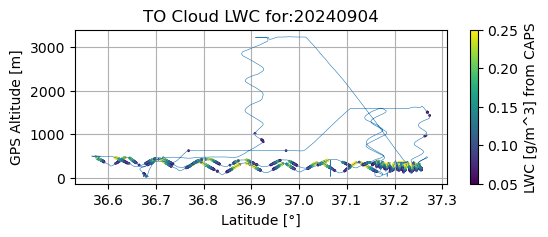

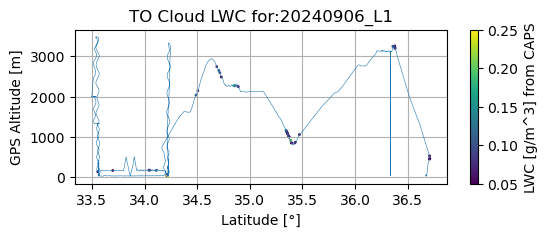

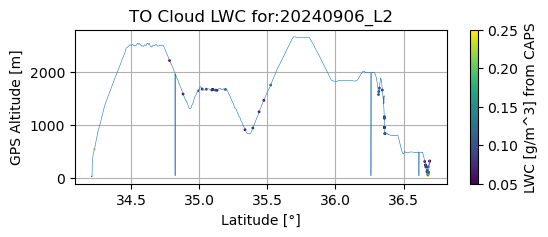

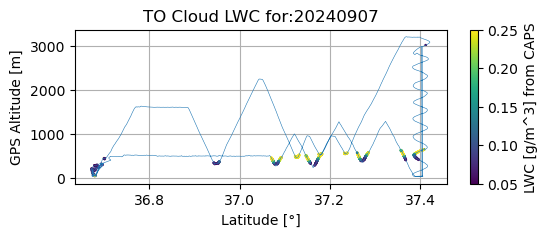

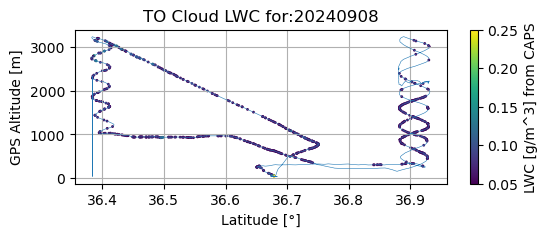

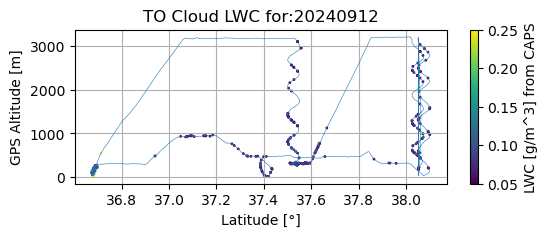

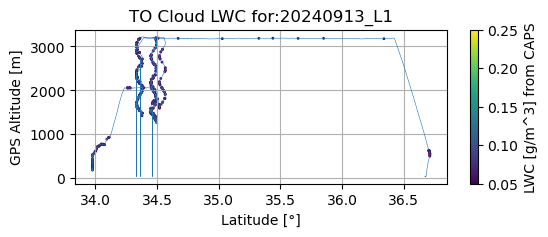

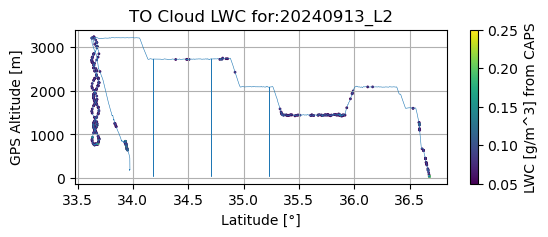

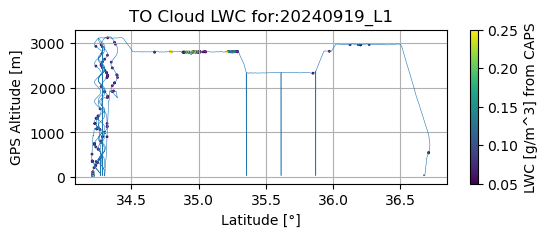

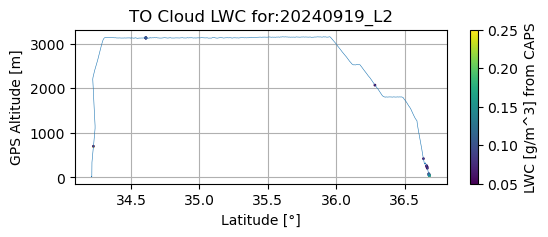

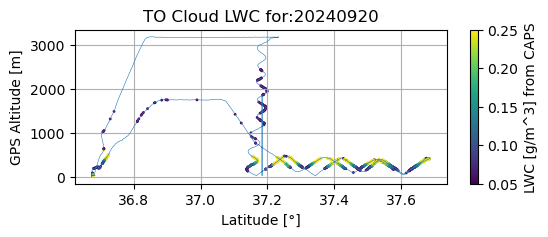

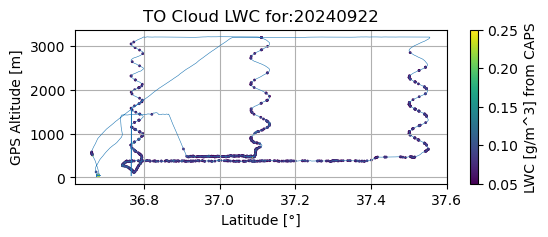

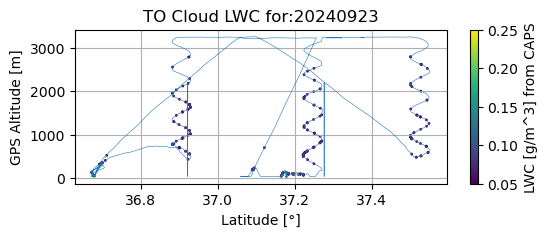

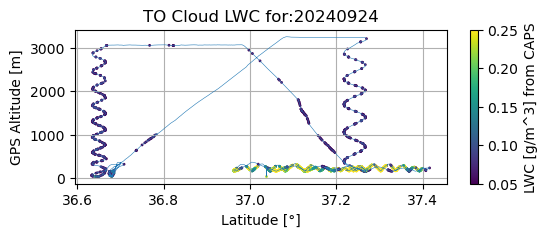

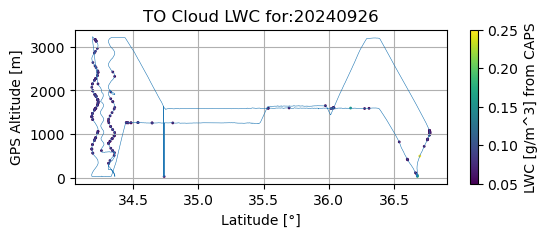

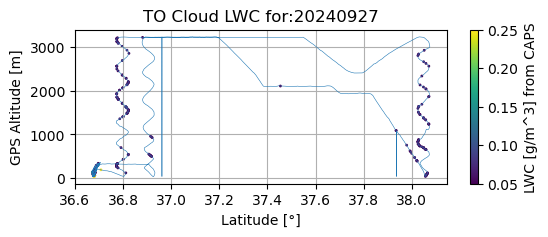

In [92]:
for k in list(metnav.keys()):
    plt.figure(figsize=(6,2))
    plt.plot(metnav[k]['Latitude'],metnav[k]['GPS_Altitude'],lw=0.4)#'.',color='gray')
    mask = metnav[k]['LWC_Wire'] > 0.05
    p = plt.scatter(metnav[k]['Latitude'][mask],metnav[k]['GPS_Altitude'][mask],1,marker='o',c=metnav[k]['LWC_Wire'][mask], vmin=0.05, vmax=0.25)
    plt.xlabel('Latitude [°]')
    plt.ylabel('GPS Altitude [m]')
    plt.title('TO Cloud LWC for:'+k)
    plt.colorbar(label='LWC [g/m^3] from CAPS')
    plt.grid()

## Plot out the cloud and aerosol time trace

In [95]:
%matplotlib inline

In [93]:
import matplotlib.colors as mcolors

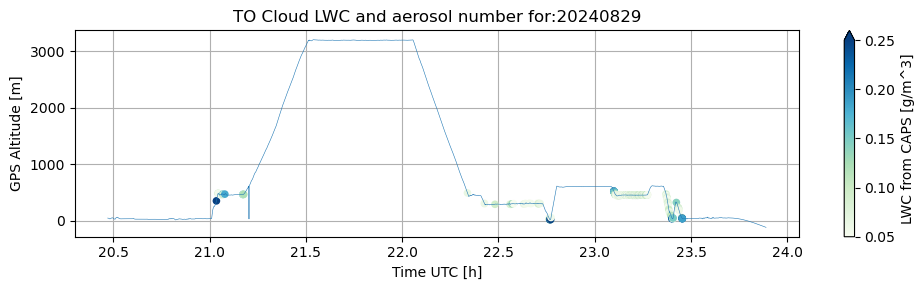

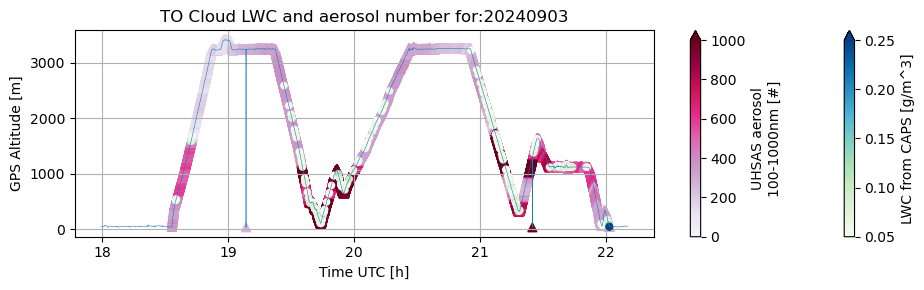

In [101]:
for k in list(metnav.keys()):
    plt.figure(figsize=(10,3))
    plt.plot(metnav[k]['Time_Start']/3600.0,metnav[k]['GPS_Altitude'],lw=0.4,zorder=3)#'.',color='gray')
    mask = metnav[k]['LWC_Wire'] > 0.05
    p = plt.scatter(metnav[k]['Time_Start'][mask]/3600.0,metnav[k]['GPS_Altitude'][mask],20,cmap='GnBu',
                    marker='o',c=metnav[k]['LWC_Wire'][mask], vmin=0.05, vmax=0.25,zorder=2)
    plt.colorbar(label='LWC from CAPS [g/m^3]',extend="max")
    plt.xlabel('Time UTC [h]')
    plt.ylabel('GPS Altitude [m]')
    plt.title('TO Cloud LWC and aerosol number for:'+k)
    plt.grid()
    try:
        fl = aer[k]['IntegN_100to1000nm_UHSAS'] > 50
        norm = mcolors.LogNorm(vmin=1, vmax=50000)
        pa = plt.scatter(aer[k]['Time_Mid'][fl]/3600.0,aern[k]['GPS_Altitude'][fl],40,marker='^',
                         c=aer[k]['IntegN_100to1000nm_UHSAS'][fl],cmap='PuRd',zorder=1,vmin=0,vmax=1000)
        plt.colorbar(label='UHSAS aerosol\n100-1000nm [#]',extend="max")
    except KeyError:
        pass
    plt.tight_layout()
    if k=='20240903':
        #plt.xlim(19.5,21)
        break
    
    #plt.savefig(fp+f'PACE-PAX_TO_LWC_aerosolnum_{k}.png',transparent=True,dpi=600)